# Coin Classification Base Model — 4 Classes

This notebook trains a custom CNN for:

- `10_cent`
- `20_cent`
- `50_cent`
- `1_dollar`

It includes dataset loading, augmentation, training, evaluation, model saving, confusion matrix, and single-image prediction.

> Each image should contain one main cropped coin. Unknown-object handling can be added later.



## Expected dataset structure

Prepare the dataset before running the notebook:

```text
coin_dataset/
├── train/
│   ├── 10_cent/
│   ├── 20_cent/
│   ├── 50_cent/
│   ├── 1_dollar/
├── validation/
│   ├── 10_cent/
│   ├── 20_cent/
│   ├── 50_cent/
│   ├── 1_dollar/
└── test/
    ├── 10_cent/
    ├── 20_cent/
    ├── 50_cent/
    ├── 1_dollar/
    └── unknown/
```

Each image should contain one main object. Front/back and old/new coin variations belong in the same denomination folder.


In [ ]:

# Uncomment when running in a fresh environment.
# %pip install -q tensorflow matplotlib scikit-learn pillow


In [32]:

from pathlib import Path
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.21.0
GPU devices: []


## 1. Configuration

In [33]:

# Change this path to the location of your dataset.
DATASET_DIR = Path("dataset2")

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

IMG_SIZE = (160, 160)
BATCH_SIZE = 8
SEED = 42
EPOCHS = 50

EXPECTED_CLASSES = ["10_cent", "20_cent", "50_cent", "1_dollar"]

for directory in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not directory.exists():
        raise FileNotFoundError(
            f"Missing folder: {directory.resolve()}\n"
            "Create the dataset structure shown above or update DATASET_DIR."
        )

print("Dataset folder:", DATASET_DIR.resolve())


Dataset folder: C:\Users\jiale\Downloads\MLAI project\dataset2


## 2. Load training, validation and test data

In [34]:

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED,
)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print("Detected classes:", CLASS_NAMES)

if CLASS_NAMES != sorted(EXPECTED_CLASSES):
    print(
        "Warning: Keras sorts folder names alphabetically. "
        "The detected classes are valid as long as all five expected folders are present."
    )

missing = sorted(set(EXPECTED_CLASSES) - set(CLASS_NAMES))
if missing:
    raise ValueError(f"Missing expected class folders: {missing}")


Found 80 files belonging to 4 classes.
Found 8 files belonging to 4 classes.
Found 12 files belonging to 4 classes.
Detected classes: ['10_cent', '1_dollar', '20_cent', '50_cent']


## 3. Inspect class balance

Training counts: {'10_cent': 20, '1_dollar': 20, '20_cent': 20, '50_cent': 20}
Validation counts: {'10_cent': 2, '1_dollar': 2, '20_cent': 2, '50_cent': 2}
Testing counts: {'10_cent': 3, '1_dollar': 3, '20_cent': 3, '50_cent': 3}


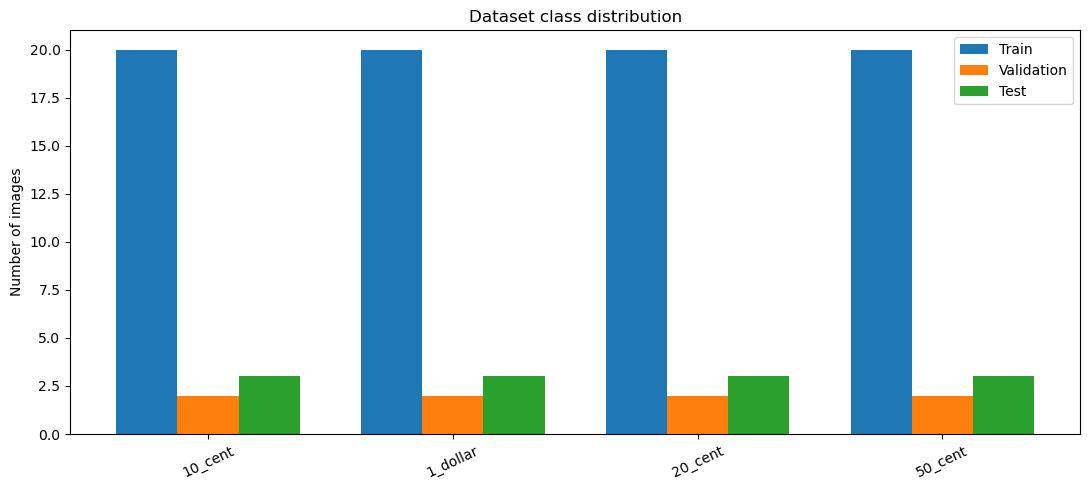

In [35]:

def count_images_by_class(directory: Path):
    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
    counts = {}
    for class_name in CLASS_NAMES:
        class_dir = directory / class_name
        counts[class_name] = sum(
            1 for file in class_dir.rglob("*")
            if file.is_file() and file.suffix.lower() in valid_extensions
        )
    return counts

train_counts = count_images_by_class(TRAIN_DIR)
val_counts = count_images_by_class(VAL_DIR)
test_counts = count_images_by_class(TEST_DIR)

print("Training counts:", train_counts)
print("Validation counts:", val_counts)
print("Testing counts:", test_counts)

x = np.arange(len(CLASS_NAMES))
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, [train_counts[c] for c in CLASS_NAMES], width, label="Train")
plt.bar(x, [val_counts[c] for c in CLASS_NAMES], width, label="Validation")
plt.bar(x + width, [test_counts[c] for c in CLASS_NAMES], width, label="Test")
plt.xticks(x, CLASS_NAMES, rotation=25)
plt.ylabel("Number of images")
plt.title("Dataset class distribution")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Display sample images

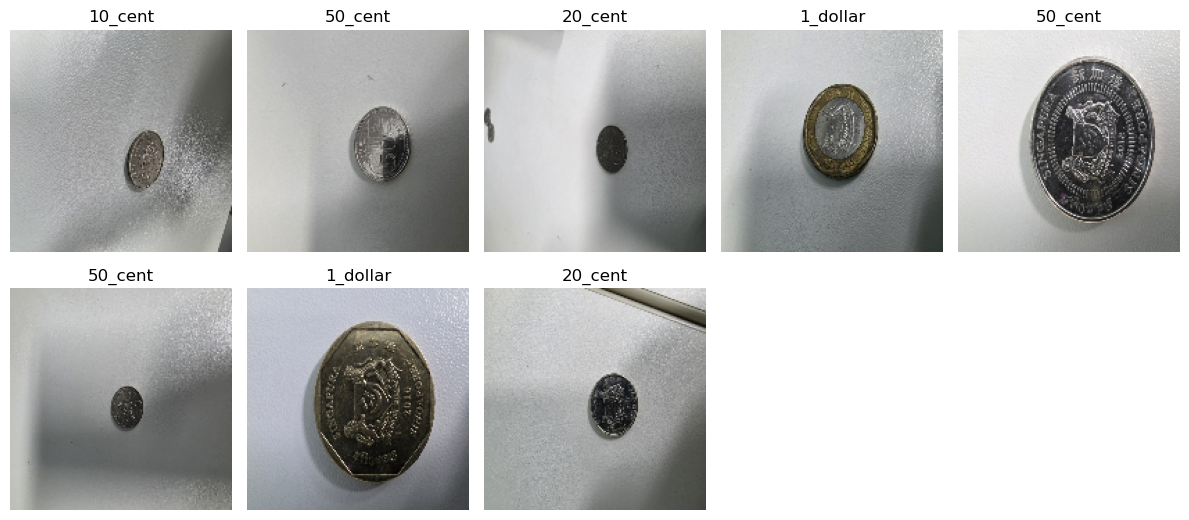

In [36]:

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    number_to_show = min(15, len(images))
    for i in range(number_to_show):
        plt.subplot(3, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = int(np.argmax(labels[i].numpy()))
        plt.title(CLASS_NAMES[label_index])
        plt.axis("off")

plt.tight_layout()
plt.show()



## 5. Data augmentation

Coins can appear at any rotation. The augmentation therefore includes full rotation, small translation, zoom, contrast and brightness changes.

Augmentation is applied only during training.


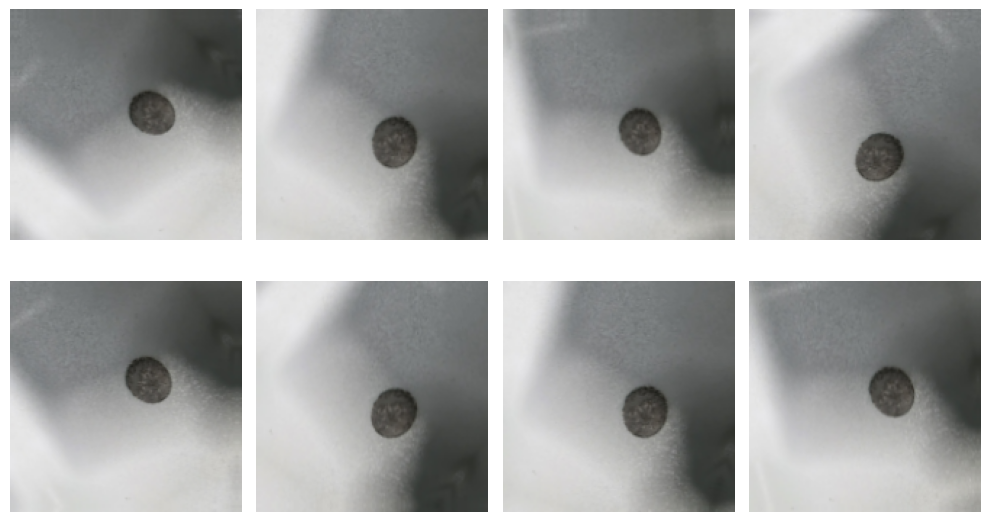

In [37]:

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.03, 0.03),
], name="coin_augmentation")

for images, _ in train_ds.take(1):
    sample = images[0]
    plt.figure(figsize=(10, 6))
    for i in range(8):
        augmented = data_augmentation(tf.expand_dims(sample, 0), training=True)
        plt.subplot(2, 4, i + 1)
        plt.imshow(tf.cast(augmented[0], tf.uint8))
        plt.axis("off")
    plt.tight_layout()
    plt.show()


## 6. Improve input performance

In [38]:

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


## 7. Build the custom CNN base model

In [39]:

def build_coin_cnn(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.0003
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_coin_cnn()
model.summary()


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ coin_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,844 (93.14 KB)

 Trainable params: 23,844 (93.14 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train and save the best model

In [40]:

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "coin_cnn_4_class_best.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

start_time = time.perf_counter()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

training_time = time.perf_counter() - start_time
print(f"Training time: {training_time:.2f} seconds")
print("Best model saved to:", BEST_MODEL_PATH.resolve())


Epoch 1/50


c:\Users\jiale\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2344 - loss: 1.4081
Epoch 1: val_accuracy improved from None to 0.25000, saving model to models\coin_cnn_4_class_best.keras

Epoch 1: finished saving model to models\coin_cnn_4_class_best.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.2250 - loss: 1.4006 - val_accuracy: 0.2500 - val_loss: 1.3883 - learning_rate: 3.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2500 - loss: 1.3893
Epoch 2: val_accuracy did not improve from 0.25000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2500 - loss: 1.3893 - val_accuracy: 0.2500 - val_loss: 1.3862 - learning_rate: 3.0000e-04
Epoch 3/50
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2639 - loss: 1.3831  
Epoch 3: val_accuracy did not improve from 0.25000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2500 - loss: 1.3874 - val_accuracy: 0.2500 - val_loss: 1.3860 - learning_rate: 3.0000e-04
Epoch 4/50
 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/

## 9. Plot accuracy and loss

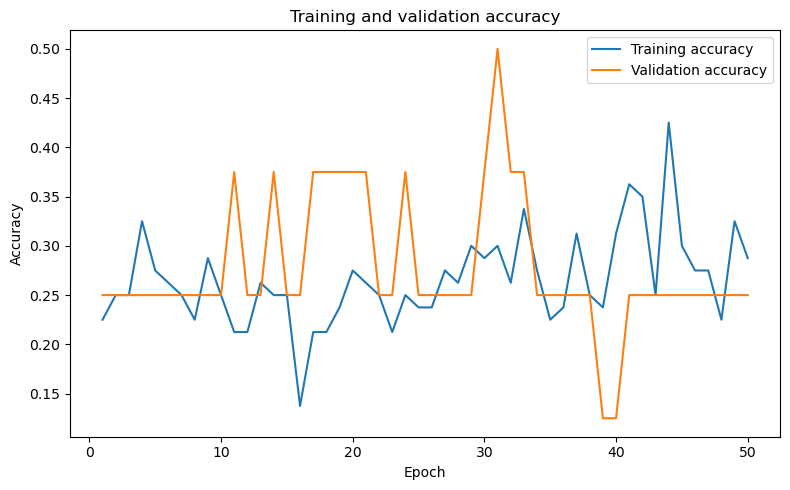

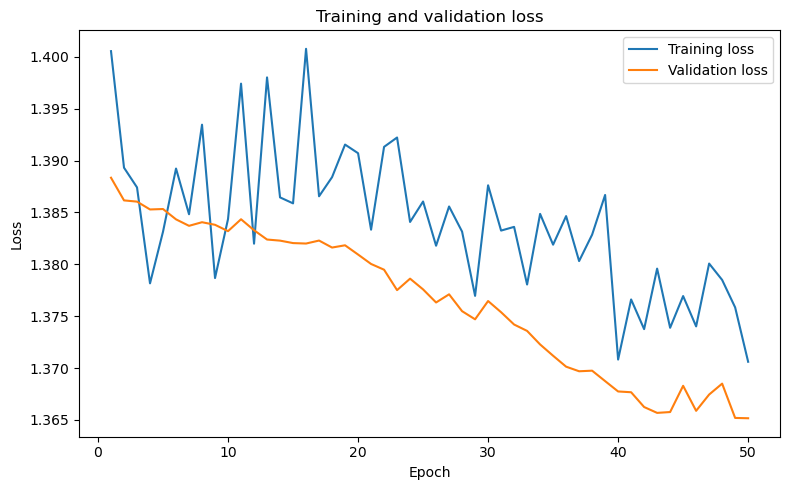

In [41]:

def plot_training_history(history):
    history_data = history.history
    epochs = range(1, len(history_data["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history_data["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_data["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history_data["loss"], label="Training loss")
    plt.plot(epochs, history_data["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_training_history(history)


## 10. Evaluate on the test set

In [27]:

best_model = keras.models.load_model(BEST_MODEL_PATH)

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

probabilities = best_model.predict(test_ds, verbose=1)
predicted_indices = np.argmax(probabilities, axis=1)

true_indices = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for _, labels in test_ds
])

print(
    classification_report(
        true_indices,
        predicted_indices,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2500 - loss: 1.4310    
Test loss: 1.4310
Test accuracy: 0.2500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 
              precision    recall  f1-score   support

     10_cent     0.0000    0.0000    0.0000         3
    1_dollar     0.2500    1.0000    0.4000         3
     20_cent     0.0000    0.0000    0.0000         3
     50_cent     0.0000    0.0000    0.0000         3

    accuracy                         0.2500        12
   macro avg     0.0625    0.2500    0.1000        12
weighted avg     0.0625    0.2500    0.1000        12



## 11. Confusion matrix

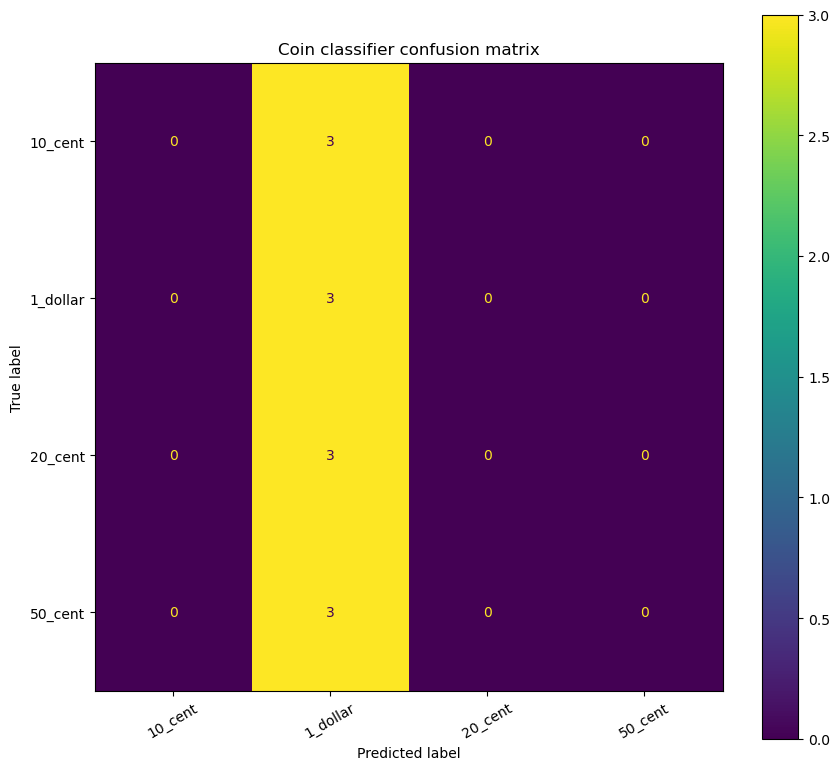

In [43]:

cm = confusion_matrix(true_indices, predicted_indices)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
)

fig, ax = plt.subplots(figsize=(9, 8))
display.plot(ax=ax, xticks_rotation=30, values_format="d")
plt.title("Coin classifier confusion matrix")
plt.tight_layout()
plt.show()


## 12. Single-image prediction

This section predicts one of the four supported coin classes.

In [29]:
def predict_single_image(image_path, model=best_model):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    image = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    image_array = keras.utils.img_to_array(image)
    batch = np.expand_dims(image_array, axis=0)

    probabilities = model.predict(batch, verbose=0)[0]
    class_index = int(np.argmax(probabilities))

    return {
        "label": CLASS_NAMES[class_index],
        "confidence": float(probabilities[class_index]),
        "probabilities": {
            class_name: float(probability)
            for class_name, probability in zip(CLASS_NAMES, probabilities)
        },
    }

# Example:
# result = predict_single_image("sample_images/test_coin.jpg")
# print(json.dumps(result, indent=2))


## 13. Display a prediction

In [30]:

def show_prediction(image_path):
    result = predict_single_image(image_path)

    image = keras.utils.load_img(image_path)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"{result['label']}\n"
        f"Confidence: {result['confidence']:.2%}"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print(json.dumps(result, indent=2))

# Example:
# show_prediction("sample_images/test_coin.jpg")


## 14. Save class names and configuration

In [31]:

config = {
    "class_names": CLASS_NAMES,
    "image_size": list(IMG_SIZE),
        "model_path": str(BEST_MODEL_PATH),
    "number_of_classes": NUM_CLASSES,
}

config_path = MODEL_DIR / "coin_4_class_config.json"
config_path.write_text(json.dumps(config, indent=2), encoding="utf-8")

print("Configuration saved to:", config_path.resolve())


Configuration saved to: C:\Users\jiale\Downloads\MLAI project\models\coin_4_class_config.json


## Adding unknown-object handling later

Yes, unknown-object handling can be added later.

Two options are available:

1. **Confidence rejection:** keep this four-class model and return `unknown` when the highest confidence is below a chosen threshold. This is quick but less reliable.
2. **Explicit unknown class:** add an `unknown` dataset folder, change the final output to five classes, and retrain the model. This is usually more reliable.

Your four-class images and most of this notebook can be reused.